# Soybean Yield Prediction Pipeline - v5 (Model Factory)
Standardized soil / weather / target-unit pipeline. Compares XGBoost,
LightGBM, and CatBoost with temporal CV, tunes them with Optuna, then
combines them into a stacked ensemble (Ridge meta-learner) as the final
model. Also trains and saves a separate model for each week-range /
weather-variable combo you define, so any of them can be loaded later
on their own.



##  STEP 0 - Setup: Install Libraries & Import
Installs XGBoost, LightGBM, CatBoost, Optuna. Imports data, plotting,
and modeling libraries used throughout the pipeline.

In [1]:
!pip install xgboost lightgbm catboost optuna --quiet

import warnings, json, os, re, time
from dataclasses import dataclass, field
from typing import Callable, Optional
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, joblib
from sklearn.ensemble import StackingRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.base import clone
import xgboost as xgb
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import optuna
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi':120})




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 12.6 MB/s eta 0:00:00


##  STEP 1 — Country Configuration
Single source of truth mapping raw column names to standardized names
(soil, weekly weather, region, target unit). Parameterized by growing-
season week window and which weather variables to include. Kept generic in structure, but
only `USA` is active.

In [2]:
@dataclass
class CountryConfig:
    country_code: str
    raw_path: str
    weather_vars: dict                      # {std_name: raw_prefix}
    weekly_col_pattern: Callable[[str, int], str]
    growing_season_weeks: list
    soil_vars: dict                         # {std_name: raw_prefix}
    soil_depth_regex: Callable[[str], "re.Pattern"]
    region_col: str
    lat_col: str
    lon_col: str
    year_col: str
    raw_target_col: str
    target_unit_to_kg_per_ha: float
    valid_target_range_kg_ha: tuple
    id_cols_to_drop: list = field(default_factory=list)
    baseline_year: int = 1980
    fixed_folds: list = field(default_factory=list)


# ── All 6 weekly weather variables (W_1 .. W_6) available in the raw data ──
# id : std_name : raw column prefix
FULL_WEATHER_VARS = {
    1: ("precipitation",           "W_1"),
    2: ("solar_radiation",         "W_2"),
    3: ("snow_water_equivalent",   "W_3"),
    4: ("maximum_temperature",     "W_4"),
    5: ("minimum_temperature",     "W_5"),
    6: ("vapor_pressure",          "W_6"),
}


def make_usa_config(season_start_week=14, season_end_week=40, excluded_weather_ids=None):
    """Factory for the USA CountryConfig, parameterized so it can be rebuilt
    for different growing-season windows and/or different subsets of the
    W_1..W_6 weekly weather variables without touching the class itself.

    season_start_week / season_end_week -> i and j in "w_y_(i) to w_y_(j)"
        (inclusive on both ends, e.g. 14, 40 -> weeks 14,15,...,40).
    excluded_weather_ids -> any subset of {1,2,3,4,5,6} (the "y" in w_y_) to
        drop from the feature set entirely, e.g. [3] removes W_3
        (snow_water_equivalent) from training.
    """
    excluded_weather_ids = set(excluded_weather_ids or [])
    active_weather_vars = {
        std_name: prefix
        for wid, (std_name, prefix) in FULL_WEATHER_VARS.items()
        if wid not in excluded_weather_ids
    }

    return CountryConfig(
        country_code="USA",
        raw_path="khaki_multi_crop_yield.csv",
        weather_vars=active_weather_vars,
        weekly_col_pattern=lambda prefix, week: f"{prefix}_{week}",
        # inclusive week range i..j (soybean growing season default: 14-40)
        growing_season_weeks=list(range(season_start_week, season_end_week + 1)),
        soil_vars={
            "bulk_density": "bdod", "cation_exchange_capacity": "cec",
            "coarse_fragments": "cfvo", "clay_content": "clay",
            "total_nitrogen": "nitrogen", "organic_carbon_density": "ocd",
            "organic_carbon_stocks": "ocs", "soil_ph": "phh2o",
            "sand_content": "sand", "silt_content": "silt",
            "soil_organic_carbon": "soc",
        },
        soil_depth_regex=lambda prefix: re.compile(rf"^{prefix}_mean_(.+)$"),
        region_col="State", lat_col="lat", lon_col="lng", year_col="year",
        raw_target_col="soybean_yield",
        target_unit_to_kg_per_ha=67.25,   # 1 Bu/Acre soybean ≈ 67.25 kg/ha
        valid_target_range_kg_ha=(5 * 67.25, 100 * 67.25),
        id_cols_to_drop=["corn_yield", "winter_wheat_yield"],
        baseline_year=1980,
        fixed_folds=[
            {"train_max_year": 2013, "test_year": 2014},
            {"train_max_year": 2014, "test_year": 2015},
            {"train_max_year": 2015, "test_year": 2016},
            {"train_max_year": 2016, "test_year": 2017},
            {"train_max_year": 2017, "test_year": 2018},
        ],
    )


# ── Tunable knobs for THIS run ───────────────────────────────────────────
# i, j : growing-season week window (inclusive). Soybean growing season ->
# week 14 to week 40, so this replaces the old whole-year (1-52) training.
SEASON_START_WEEK = 14      # i
SEASON_END_WEEK   = 40      # j

# Drop any of the 6 weekly weather variables (the "y" in w_y_) from training
# by adding their id (1-6) here, e.g. EXCLUDED_WEATHER_IDS = [3, 5]. Leave
# empty to keep all 6.
EXCLUDED_WEATHER_IDS = [3]

cfg = make_usa_config(SEASON_START_WEEK, SEASON_END_WEEK, EXCLUDED_WEATHER_IDS)

print(f"Active config: {cfg.country_code}  ->  {cfg.raw_path}")
print(f"Growing season weeks: {cfg.growing_season_weeks[0]}-{cfg.growing_season_weeks[-1]} "
      f"({len(cfg.growing_season_weeks)} weeks)")
print(f"Active weather variables ({len(cfg.weather_vars)}/6): {list(cfg.weather_vars.keys())}")


Active config: USA  ->  khaki_multi_crop_yield.csv
Growing season weeks: 14-40 (27 weeks)
Active weather variables (5/6): ['precipitation', 'solar_radiation', 'maximum_temperature', 'minimum_temperature', 'vapor_pressure']


##  STEP 2 - Load Raw Data
Mounts Google Drive and loads the raw CSV from there.

In [3]:
import os


from google.colab import drive
drive.mount('/content/drive')

RAW_PATH = '/content/drive/MyDrive/khaki_multi_crop_yield.csv'

raw = pd.read_csv(RAW_PATH)
print(f"Loaded {RAW_PATH}: {len(raw):,} rows x {raw.shape[1]} columns")


Mounted at /content/drive
Loaded /content/drive/MyDrive/khaki_multi_crop_yield.csv: 25,306 rows x 401 columns


##  STEP 3 - Standardize + Clean
Converts the raw target to kg/ha, drops missing/duplicate rows,
standardizes region/lat/lon/year, removes yield outliers per region
(IQR x3), and clips to a physically valid yield range.

STEP 3 — Standardizing & Cleaning
  Dropped 0 rows with missing target. Remaining: 25306
  Dropped 0 exact duplicate rows.
  Removed 0 extreme yield outliers (IQR x3 per region).
  Clipped to [336, 6725] kg/ha; removed 2 rows. Final: 25304


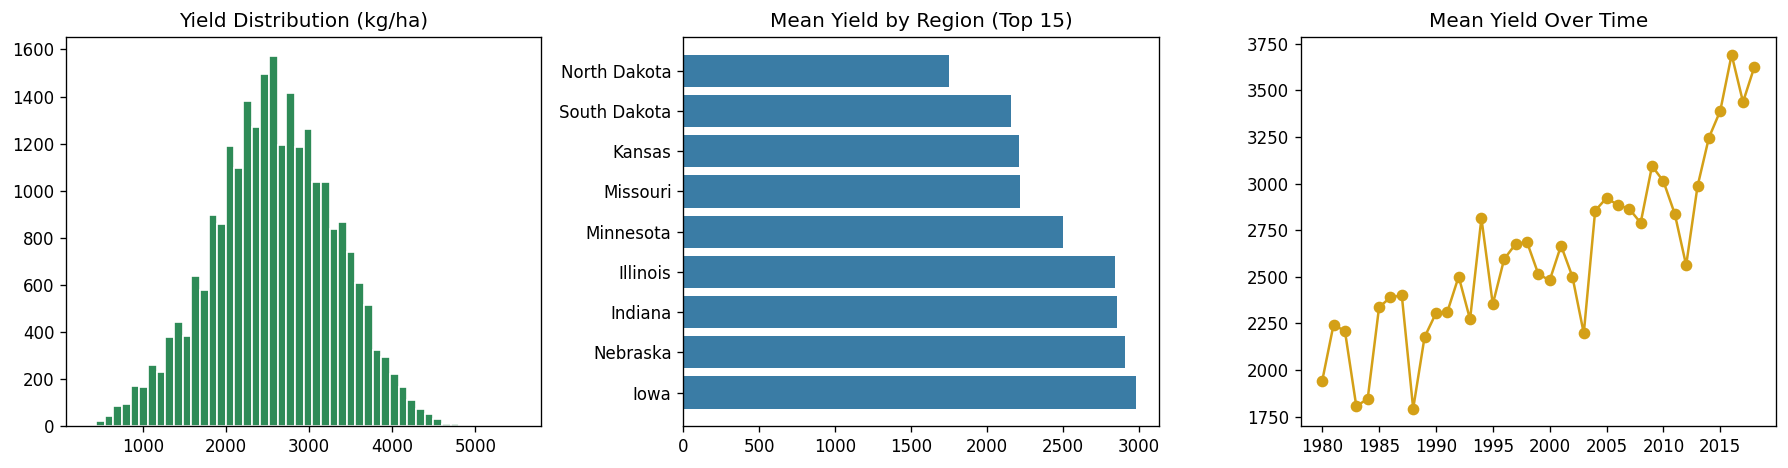

In [4]:
def standardize_and_clean(df_raw: pd.DataFrame, cfg: CountryConfig) -> pd.DataFrame:
    print('=' * 65); print('STEP 3 — Standardizing & Cleaning'); print('=' * 65)
    df = df_raw.copy()
    df = df.drop(columns=cfg.id_cols_to_drop, errors='ignore')

    df['yield_kg_ha'] = df[cfg.raw_target_col] * cfg.target_unit_to_kg_per_ha
    before = len(df)
    df = df.dropna(subset=['yield_kg_ha'])
    print(f'  Dropped {before - len(df)} rows with missing target. Remaining: {len(df)}')

    before = len(df)
    df = df.drop_duplicates()
    print(f'  Dropped {before - len(df)} exact duplicate rows.')

    df['region'] = df[cfg.region_col].astype(str).str.strip().str.title()
    df['latitude'] = df[cfg.lat_col]
    df['longitude'] = df[cfg.lon_col]
    df['obs_year'] = df[cfg.year_col]
    df['country'] = cfg.country_code

    def iqr_outlier_mask(series, factor=3.0):
        q1, q3 = series.quantile(0.25), series.quantile(0.75)
        iqr = q3 - q1
        return (series >= q1 - factor * iqr) & (series <= q3 + factor * iqr)

    before = len(df)
    mask = df.groupby('region')['yield_kg_ha'].transform(iqr_outlier_mask)
    df = df[mask].copy()
    print(f'  Removed {before - len(df)} extreme yield outliers (IQR x3 per region).')

    lo, hi = cfg.valid_target_range_kg_ha
    before = len(df)
    df = df[(df['yield_kg_ha'] >= lo) & (df['yield_kg_ha'] <= hi)]
    print(f'  Clipped to [{lo:.0f}, {hi:.0f}] kg/ha; removed {before - len(df)} rows. Final: {len(df)}')
    return df


df_clean = standardize_and_clean(raw, cfg)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df_clean['yield_kg_ha'], bins=50, color='#2E8B57', edgecolor='white')
axes[0].set_title('Yield Distribution (kg/ha)')
yield_by_region = df_clean.groupby('region')['yield_kg_ha'].mean().sort_values(ascending=False).head(15)
axes[1].barh(yield_by_region.index, yield_by_region.values, color='#3A7CA5')
axes[1].set_title('Mean Yield by Region (Top 15)')
yield_by_year = df_clean.groupby('obs_year')['yield_kg_ha'].mean()
axes[2].plot(yield_by_year.index, yield_by_year.values, marker='o', color='#D4A017')
axes[2].set_title('Mean Yield Over Time')
plt.tight_layout()
plt.savefig('/content/eda_overview.png', bbox_inches='tight')
plt.show()

In [5]:
ARTIFACT_DIR = '/content/artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

##  STEP 4 - Feature Engineering (Soil + Micro-Climate/Weather)
Builds growing-season-only weather aggregates (mean/sum/std) and
agronomic interaction terms (diurnal temp range, heat-stress degree
days, water-balance proxy). Builds soil aggregates (depth-averaged +
topsoil) and soil-weather interactions (water-holding capacity, sand x
drought). Adds region encoding and years since baseline.

In [6]:
def engineer_features(df: pd.DataFrame, cfg: CountryConfig, region_encoder: Optional[LabelEncoder] = None):
    print('=' * 65); print('STEP 4 — Feature Engineering'); print('=' * 65)
    feat = df.copy()

    # Growing-season weather aggregates ONLY (micro-climate signal).
    # NOTE: previously this also computed a whole-year 'annual_{var}_mean'
    # from all 52 weeks (range(1, 53)), which is exactly the "used the whole
    # 52 weeks for training" issue -- soybean's growing season is weeks
    # cfg.growing_season_weeks[0]-cfg.growing_season_weeks[-1] (default 14-40),
    # so the whole-year aggregate has been removed and every weekly feature
    # below is restricted to cfg.growing_season_weeks.
    for std_name, prefix in cfg.weather_vars.items():
        gs_cols = [cfg.weekly_col_pattern(prefix, w) for w in cfg.growing_season_weeks
                   if cfg.weekly_col_pattern(prefix, w) in feat.columns]
        if gs_cols:
            feat[f'growing_season_{std_name}_mean'] = feat[gs_cols].mean(axis=1)
            feat[f'growing_season_{std_name}_sum']  = feat[gs_cols].sum(axis=1)
            feat[f'growing_season_{std_name}_std']  = feat[gs_cols].std(axis=1)

    # Weather interaction terms — capture compounding stress (heat x dryness, etc.)
    if {'growing_season_maximum_temperature_mean', 'growing_season_minimum_temperature_mean'} <= set(feat.columns):
        feat['growing_season_diurnal_temperature_range'] = (
            feat['growing_season_maximum_temperature_mean'] - feat['growing_season_minimum_temperature_mean'])
    if {'growing_season_precipitation_mean', 'growing_season_solar_radiation_mean'} <= set(feat.columns):
        feat['growing_season_precipitation_x_solar_radiation'] = (
            feat['growing_season_precipitation_mean'] * feat['growing_season_solar_radiation_mean'])
    if {'growing_season_vapor_pressure_mean', 'growing_season_maximum_temperature_mean'} <= set(feat.columns):
        feat['growing_season_vapor_pressure_x_max_temperature'] = (
            feat['growing_season_vapor_pressure_mean'] * feat['growing_season_maximum_temperature_mean'])
    # Heat-stress proxy: degree-days above 30C across growing season, if max-temp weeks exist
    max_temp_prefix = cfg.weather_vars.get('maximum_temperature')
    if max_temp_prefix:
        gs_max_cols = [cfg.weekly_col_pattern(max_temp_prefix, w) for w in cfg.growing_season_weeks
                       if cfg.weekly_col_pattern(max_temp_prefix, w) in feat.columns]
        if gs_max_cols:
            feat['growing_season_heat_stress_degree_days'] = (feat[gs_max_cols] - 30).clip(lower=0).sum(axis=1)
    # Water-balance proxy: precip minus a temperature-driven evap proxy
    if {'growing_season_precipitation_sum', 'growing_season_maximum_temperature_mean'} <= set(feat.columns):
        feat['growing_season_water_balance_proxy'] = (
            feat['growing_season_precipitation_sum'] - feat['growing_season_maximum_temperature_mean'] * 10)

    # Soil aggregates (soil signal)
    for std_name, prefix in cfg.soil_vars.items():
        pattern = cfg.soil_depth_regex(prefix)
        depth_cols = [c for c in feat.columns if pattern.match(c)]
        if depth_cols:
            feat[f'{std_name}_depth_averaged_mean'] = feat[depth_cols].mean(axis=1)
            feat[f'{std_name}_topsoil_mean'] = feat[sorted(depth_cols)[0]]
    # Soil interaction: water-holding capacity proxy (clay + organic carbon)
    if {'clay_content_depth_averaged_mean', 'soil_organic_carbon_depth_averaged_mean'} <= set(feat.columns):
        feat['soil_water_holding_proxy'] = (
            feat['clay_content_depth_averaged_mean'] + feat['soil_organic_carbon_depth_averaged_mean'])
    # Soil x weather interaction: sandy soil compounds drought stress
    if {'sand_content_depth_averaged_mean', 'growing_season_precipitation_sum'} <= set(feat.columns):
        feat['sand_x_low_precipitation'] = (
            feat['sand_content_depth_averaged_mean'] / (feat['growing_season_precipitation_sum'] + 1))

    # Region encoding
    if region_encoder is None:
        region_encoder = LabelEncoder()
        feat['region_encoded'] = region_encoder.fit_transform(feat['region'])
    else:
        feat['region_encoded'] = region_encoder.transform(feat['region'])

    feat['years_since_baseline'] = feat['obs_year'] - cfg.baseline_year
    return feat, region_encoder


feat, region_encoder = engineer_features(df_clean, cfg)
joblib.dump(region_encoder, f'{ARTIFACT_DIR}/region_encoder.joblib')
print(f'  Engineered shape: {feat.shape}')

STEP 4 — Feature Engineering
  Engineered shape: (25304, 451)


##  STEP 5 - Export Cleaned & Engineered CSV
Saves the cleaned, feature-engineered table as a checkpoint CSV.

In [7]:
OUTPUT_PATH = '/content/yield_cleaned_engineered.csv'
feat.to_csv(OUTPUT_PATH, index=False)
print(f'  Saved -> {OUTPUT_PATH}  ({len(feat):,} rows x {feat.shape[1]} cols)')

# from google.colab import files
# files.download(OUTPUT_PATH)

  Saved -> /content/yield_cleaned_engineered.csv  (25,304 rows x 451 cols)


In [8]:
import warnings
import json
import os
import re
from dataclasses import dataclass, field
from typing import Callable, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, StackingRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.cluster import KMeans
import xgboost as xgb

##  STEP 6 - K-Means Clustering (Agro-Climatic Profiles)
Clusters rows by soil + weather signature only (no lat/lon), so the
cluster represents a climate profile, not a region ID. K=4, chosen via
elbow method.

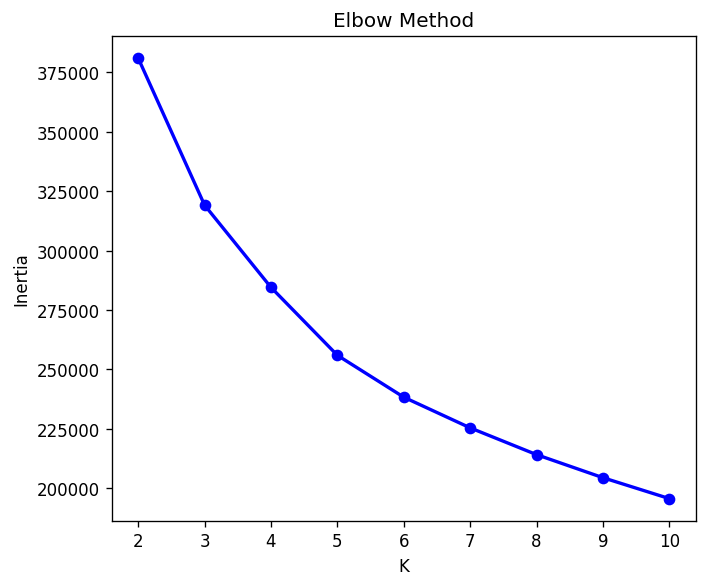

['/content/artifacts/cluster_artifacts.joblib']

In [9]:
# Soil + weather only -- intentionally NOT including latitude/longitude here,
# so the resulting cluster id is an agro-climatic profile (soil+weather
# signature) rather than a stand-in for "which region is this".
cluster_feature_cols = (
    [f'growing_season_{v}_mean' for v in cfg.weather_vars] +
    [f'growing_season_{v}_sum'  for v in cfg.weather_vars] +
    [f'{v}_depth_averaged_mean' for v in cfg.soil_vars]
)
cluster_feature_cols = [c for c in cluster_feature_cols if c in feat.columns]

X_cluster = feat[cluster_feature_cols].fillna(0).values
scaler_c = StandardScaler()
X_cluster_s = scaler_c.fit_transform(X_cluster)

inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_s)
    inertias.append(km.inertia_)

K_OPTIMAL = 4
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
feat['cluster'] = kmeans.fit_predict(X_cluster_s)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(list(K_range), inertias, 'bo-', linewidth=2)
ax.set_title('Elbow Method'); ax.set_xlabel('K'); ax.set_ylabel('Inertia')
plt.tight_layout()
plt.savefig('/content/clustering_results.png', bbox_inches='tight')
plt.show()

joblib.dump({'scaler': scaler_c, 'kmeans': kmeans, 'feature_cols': cluster_feature_cols},
            f'{ARTIFACT_DIR}/cluster_artifacts.joblib')

##  STEP 7 - Final Feature Set & Temporal Folds
Assembles the final model input list: weather + soil aggregates,
interaction terms, years_since_baseline, and cluster. Location columns
(region/lat/lon) are excluded since they wouldn't generalize to other
countries.

In [10]:
def build_feature_cols(feat: pd.DataFrame, cfg: CountryConfig) -> list:
    # Soil + micro-climate/weather, plus ONE deliberate exception:
    # years_since_baseline. region_encoded/latitude/longitude are LOCATION
    # identifiers -- categorical/coordinate stand-ins for "which US state is
    # this" that have no meaning in another country's dataset, so they're
    # excluded. years_since_baseline is different: it's a continuous TIME
    # trend (every country has a calendar) that captures real genetic/
    # technology yield improvement over the decades -- a physical driver,
    # not a memorized location. Dropping it left tree models with no way to
    # extrapolate the upward yield trend into later test years, which is why
    # removing it caused R^2 to collapse. 'cluster' is kept because it's
    # built purely from soil+weather signatures (see Step 6) -- not a
    # location proxy. 'annual_{v}_mean' (whole-year, 52-week aggregate) is
    # no longer produced by engineer_features, so it's simply absent from
    # feat.columns -- every weather feature here is growing-season-only.
    cols = (
        [f'growing_season_{v}_mean' for v in cfg.weather_vars] +
        [f'growing_season_{v}_sum'  for v in cfg.weather_vars] +
        [f'growing_season_{v}_std'  for v in cfg.weather_vars] +
        [f'{v}_depth_averaged_mean' for v in cfg.soil_vars] +
        [f'{v}_topsoil_mean'        for v in cfg.soil_vars] +
        ['growing_season_diurnal_temperature_range',
         'growing_season_precipitation_x_solar_radiation',
         'growing_season_vapor_pressure_x_max_temperature',
         'growing_season_heat_stress_degree_days',
         'growing_season_water_balance_proxy',
         'soil_water_holding_proxy',
         'sand_x_low_precipitation',
         'years_since_baseline', 'cluster']
    )
    return [c for c in cols if c in feat.columns]


TARGET = 'yield_kg_ha'
feature_cols = build_feature_cols(feat, cfg)
folds = cfg.fixed_folds

print(f'  Features used: {len(feature_cols)}')
for c in feature_cols:
    print('   -', c)

json.dump({'feature_cols': feature_cols, 'target': TARGET},
          open(f'{ARTIFACT_DIR}/feature_schema.json', 'w'), indent=2)

  Features used: 46
   - growing_season_precipitation_mean
   - growing_season_solar_radiation_mean
   - growing_season_maximum_temperature_mean
   - growing_season_minimum_temperature_mean
   - growing_season_vapor_pressure_mean
   - growing_season_precipitation_sum
   - growing_season_solar_radiation_sum
   - growing_season_maximum_temperature_sum
   - growing_season_minimum_temperature_sum
   - growing_season_vapor_pressure_sum
   - growing_season_precipitation_std
   - growing_season_solar_radiation_std
   - growing_season_maximum_temperature_std
   - growing_season_minimum_temperature_std
   - growing_season_vapor_pressure_std
   - bulk_density_depth_averaged_mean
   - cation_exchange_capacity_depth_averaged_mean
   - coarse_fragments_depth_averaged_mean
   - clay_content_depth_averaged_mean
   - total_nitrogen_depth_averaged_mean
   - organic_carbon_density_depth_averaged_mean
   - organic_carbon_stocks_depth_averaged_mean
   - soil_ph_depth_averaged_mean
   - sand_content_depth_

##  STEP 7b - Missing Value Handling
Adds a _was_missing flag for each feature with missing values, then
median-imputes. Replaces the old fillna(0), which wrongly treated
"no reading" the same as "value is zero."

In [11]:
from sklearn.impute import SimpleImputer

missing_flag_cols = []
for col in feature_cols:
    if feat[col].isna().any():
        flag_col = f'{col}_was_missing'
        feat[flag_col] = feat[col].isna().astype(int)
        missing_flag_cols.append(flag_col)

print(f'  Added {len(missing_flag_cols)} missing-value indicator flags.')
if missing_flag_cols:
    print('   -', ', '.join(missing_flag_cols))

imputer = SimpleImputer(strategy='median')
feat[feature_cols] = imputer.fit_transform(feat[feature_cols])

# Extend feature_cols with the new flags so downstream cells pick them up automatically
feature_cols = feature_cols + missing_flag_cols
joblib.dump(imputer, f'{ARTIFACT_DIR}/imputer.joblib')

json.dump({'feature_cols': feature_cols, 'target': TARGET},
          open(f'{ARTIFACT_DIR}/feature_schema.json', 'w'), indent=2)

print(f'  Final feature count (incl. missing flags): {len(feature_cols)}')


  Added 0 missing-value indicator flags.
  Final feature count (incl. missing flags): 46


##  STEP 8 - Model Factories: XGBoost, LightGBM, CatBoost
Defines the model-building functions for XGBoost, LightGBM, and
CatBoost, reused for both CV comparison and Optuna tuning below.

In [12]:
N_TRIALS = 50   # trial 1: kept modest since CatBoost trains slower per-iteration than LightGBM.
                # Raise to 200 once you've confirmed the pipeline runs end-to-end.

MODEL_FACTORIES = {
    'XGBoost': lambda p={}: xgb.XGBRegressor(random_state=42, verbosity=0, **p),
    'LightGBM': lambda p={}: LGBMRegressor(random_state=42, **p),
    'CatBoost': lambda p={}: CatBoostRegressor(random_state=42, verbose=0, **p)
}


##  STEP 13 - Train Separate Models for Different Week Ranges / Weather Variables
Repeats feature engineering, clustering, tuning, and stacking for any
week window and weather-variable subset you define, saving each run's
models to its own folder. Same Optuna-based tuning setup as soybean.

In [13]:
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans

def run_full_training(season_start_week, season_end_week, excluded_weather_ids=None,
                       n_trials=30, run_tag=None):
    """Trains + tunes + stacks a full model for one (i, j) week window and one
    weather-variable subset, mirroring Steps 6-10 above. Returns a dict with
    the fitted model, its feature columns, the CV comparison table, and where
    its artifacts were saved. Safe to call in a loop for as many (i, j,
    excluded_weather_ids) combinations as you want."""
    excluded_weather_ids = excluded_weather_ids or []
    run_cfg = make_usa_config(season_start_week, season_end_week, excluded_weather_ids)

    tag = run_tag or (
        f"weeks_{season_start_week}_{season_end_week}"
        + ("_excl" + "-".join(str(i) for i in sorted(excluded_weather_ids)) if excluded_weather_ids else "")
    )
    run_dir = f'{ARTIFACT_DIR}/{tag}'
    os.makedirs(run_dir, exist_ok=True)

    print('=' * 65)
    print(f'RUN: {tag}   weeks {season_start_week}-{season_end_week}   '
          f'excluded W_ids={excluded_weather_ids or "none"}')
    print('=' * 65)

    # Step 4 (re-run for this cfg)
    feat_r, region_encoder_r = engineer_features(df_clean, run_cfg)

    # Step 6 (re-run for this cfg's feature set)
    cluster_cols_r = (
        [f'growing_season_{v}_mean' for v in run_cfg.weather_vars] +
        [f'growing_season_{v}_sum'  for v in run_cfg.weather_vars] +
        [f'{v}_depth_averaged_mean' for v in run_cfg.soil_vars]
    )
    cluster_cols_r = [c for c in cluster_cols_r if c in feat_r.columns]
    Xc = feat_r[cluster_cols_r].fillna(0).values
    scaler_c_r = StandardScaler()
    Xc_s = scaler_c_r.fit_transform(Xc)
    kmeans_r = KMeans(n_clusters=4, random_state=42, n_init=10)
    feat_r['cluster'] = kmeans_r.fit_predict(Xc_s)

    # Step 7
    feature_cols_r = build_feature_cols(feat_r, run_cfg)

    # Step 7b
    missing_flags_r = []
    for col in feature_cols_r:
        if feat_r[col].isna().any():
            fc = f'{col}_was_missing'
            feat_r[fc] = feat_r[col].isna().astype(int)
            missing_flags_r.append(fc)
    imputer_r = SimpleImputer(strategy='median')
    feat_r[feature_cols_r] = imputer_r.fit_transform(feat_r[feature_cols_r])
    feature_cols_r = feature_cols_r + missing_flags_r

    print(f'  Features used: {len(feature_cols_r)}  |  rows: {len(feat_r):,}')

    X_all_r = feat_r[feature_cols_r].values
    y_all_r = feat_r[TARGET].values
    tscv_r = TimeSeriesSplit(n_splits=5)

    # Step 9 -- hyperparameter search (reuses MODEL_FACTORIES from Step 8)
    def objective_r(trial, model_name):
        if model_name == 'XGBoost':
            params = {'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
                      'max_depth': trial.suggest_int('max_depth', 3, 10),
                      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3)}
        elif model_name == 'LightGBM':
            params = {'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
                      'num_leaves': trial.suggest_int('num_leaves', 20, 100),
                      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3)}
        else:  # CatBoost
            params = {'iterations': trial.suggest_int('iterations', 100, 1000),
                      'depth': trial.suggest_int('depth', 4, 10),
                      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3)}
        model = MODEL_FACTORIES[model_name](params)
        scores = []
        for tr, te in tscv_r.split(X_all_r):
            model.fit(X_all_r[tr], y_all_r[tr])
            pred = model.predict(X_all_r[te])
            scores.append(mean_squared_error(y_all_r[te], pred))
        return np.mean(scores)

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    best_params_r = {}
    for m in MODEL_FACTORIES:
        study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
        study.optimize(lambda t: objective_r(t, m), n_trials=n_trials)
        best_params_r[m] = study.best_params
        print(f'  Optuna best for {m}: {study.best_params}  (CV MSE={study.best_value:.4f})')

    # Step 10 -- stacked ensemble vs tuned individual models
    final_candidates_r = {m: MODEL_FACTORIES[m](best_params_r[m]) for m in MODEL_FACTORIES}
    stack_r = StackingRegressor(
        estimators=[('xgb', final_candidates_r['XGBoost']),
                    ('lgbm', final_candidates_r['LightGBM']),
                    ('cat', final_candidates_r['CatBoost'])],
        final_estimator=Ridge(alpha=1.0),
    )
    final_candidates_r['Stacking Ensemble'] = stack_r

    rows = []
    oof_actual_r, oof_pred_r = {}, {}   # out-of-fold actual/predicted, kept for the scatter plot below
    for name, model in final_candidates_r.items():
        rmses, r2s = [], []
        fold_actuals, fold_preds = [], []
        for tr, te in tscv_r.split(X_all_r):
            model.fit(X_all_r[tr], y_all_r[tr])
            pred = model.predict(X_all_r[te])
            rmses.append(np.sqrt(mean_squared_error(y_all_r[te], pred)))
            r2s.append(r2_score(y_all_r[te], pred))
            fold_actuals.append(y_all_r[te])
            fold_preds.append(pred)
        rows.append([name, np.mean(rmses), np.mean(r2s)])
        oof_actual_r[name] = np.concatenate(fold_actuals)
        oof_pred_r[name] = np.concatenate(fold_preds)

    summary_r = (pd.DataFrame(rows, columns=['Model', 'Mean RMSE (kg/ha)', 'Mean R²'])
                 .sort_values('Mean RMSE (kg/ha)').reset_index(drop=True))
    # NOTE: no model is auto-selected as "the best" here. XGBoost, LightGBM,
    # CatBoost, and the Stacking Ensemble are all trained, compared, and
    # saved on equal footing -- picking which one to actually use for this
    # week range is left for later, by you.

    # Save this run's shared artifacts (doesn't touch the main run). No single
    # "final_model.joblib" is written here since no model is picked; every
    # candidate is saved individually below, in model_factory/<tag>/<ModelName>/.
    joblib.dump(region_encoder_r, f'{run_dir}/region_encoder.joblib')
    joblib.dump(imputer_r, f'{run_dir}/imputer.joblib')
    json.dump(
        {'feature_cols': feature_cols_r, 'target': TARGET,
         'season_start_week': season_start_week, 'season_end_week': season_end_week,
         'excluded_weather_ids': excluded_weather_ids,
         'best_params': best_params_r},
        open(f'{run_dir}/feature_schema.json', 'w'), indent=2,
    )
    summary_r.to_csv(f'{run_dir}/model_comparison.csv', index=False)

    print(f'  Model comparison for this run ({tag}):')
    display(summary_r)

    # Fixed display order for every per-model plot below (★ marks whichever
    # model actually won this run's RMSE comparison -- that can change
    # between week-range runs, so it's computed fresh each time).
    MODEL_PLOT_ORDER = ['XGBoost', 'LightGBM', 'CatBoost', 'Stacking Ensemble']
    MODEL_PLOT_ORDER = [m for m in MODEL_PLOT_ORDER if m in oof_actual_r]

    # ---- Predicted vs. Actual scatter plots -- ALL models, not just the best one ----
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    for ax, name in zip(axes.flat, MODEL_PLOT_ORDER):
        y_true_plot = oof_actual_r[name]
        y_pred_plot = oof_pred_r[name]
        lims = [min(y_true_plot.min(), y_pred_plot.min()), max(y_true_plot.max(), y_pred_plot.max())]
        ax.scatter(y_true_plot, y_pred_plot, alpha=0.4, color='#3A7CA5', edgecolor='none', s=18)
        ax.plot(lims, lims, '--', color='#D4A017', linewidth=2, label='Perfect prediction')
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel('Actual Yield (kg/ha)')
        ax.set_ylabel('Predicted Yield (kg/ha)')
        ax.set_title(f'{name}', fontsize=11)
        ax.legend(fontsize=8)
    fig.suptitle(f'Predicted vs. Actual — {tag} (out-of-fold, all models)', y=1.02, fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{run_dir}/predicted_vs_actual_all_models.png', bbox_inches='tight')
    plt.show()

    # ================================================================
    # ADDED — save EVERY trained model (not just the best one) into its
    # own folder inside a top-level `model_factory` directory, so each
    # model type for each week-range run can be loaded independently
    # later (e.g. by the separate prediction notebook) without needing
    # the others. Nothing above this block was changed.
    # ================================================================

    # Cluster artifacts were previously only saved for the single "main
    # run" (Step 6). Saving them here too, per run, so the 'cluster'
    # feature can be reproduced exactly at inference time for EVERY
    # week-range run, not just the main one.
    cluster_artifacts_r = {'scaler': scaler_c_r, 'kmeans': kmeans_r, 'feature_cols': cluster_cols_r}
    joblib.dump(cluster_artifacts_r, f'{run_dir}/cluster_artifacts.joblib')

    # Raw soil-depth column names actually present in this dataset, captured
    # once per run so a prediction pipeline knows exactly which raw soil
    # columns to ask the user for (these names come straight from the
    # source CSV and can't be derived from std_name/prefix alone).
    soil_raw_cols_r = {}
    for std_name_s, prefix_s in run_cfg.soil_vars.items():
        pattern_s = run_cfg.soil_depth_regex(prefix_s)
        depth_cols_s = sorted([c for c in feat_r.columns if pattern_s.match(c)])
        if depth_cols_s:
            soil_raw_cols_r[std_name_s] = depth_cols_s

    MODEL_FACTORY_DIR = f'{ARTIFACT_DIR}/model_factory'
    run_factory_dir = f'{MODEL_FACTORY_DIR}/{tag}'
    os.makedirs(run_factory_dir, exist_ok=True)

    fitted_full_models_r = {}   # every model type fit on all data, kept for feature importance below
    for name_f, model_f in final_candidates_r.items():
        # Every candidate is (re)fit on ALL available data here, on equal
        # footing -- none of them is treated as "the" model for this run.
        model_final_f = clone(model_f)
        model_final_f.fit(X_all_r, y_all_r)
        fitted_full_models_r[name_f] = model_final_f

        model_dir_f = f"{run_factory_dir}/{name_f.replace(' ', '_')}"
        os.makedirs(model_dir_f, exist_ok=True)

        joblib.dump(model_final_f, f'{model_dir_f}/model.joblib')
        joblib.dump(region_encoder_r, f'{model_dir_f}/region_encoder.joblib')
        joblib.dump(imputer_r, f'{model_dir_f}/imputer.joblib')
        joblib.dump(cluster_artifacts_r, f'{model_dir_f}/cluster_artifacts.joblib')

        row_f = summary_r.loc[summary_r['Model'] == name_f].iloc[0]
        json.dump(
            {
                'model_name': name_f,
                'feature_cols': feature_cols_r,               # final order, incl. *_was_missing flags
                'target': TARGET,
                'season_start_week': season_start_week,
                'season_end_week': season_end_week,
                'excluded_weather_ids': excluded_weather_ids,
                'growing_season_weeks': run_cfg.growing_season_weeks,
                'weather_vars': run_cfg.weather_vars,          # {std_name: raw_prefix}
                'soil_vars': run_cfg.soil_vars,                # {std_name: raw_prefix}
                'soil_raw_cols': soil_raw_cols_r,              # {std_name: [raw depth columns]}
                'baseline_year': run_cfg.baseline_year,
                'region_classes': list(region_encoder_r.classes_),
                'best_params': best_params_r.get(name_f, {}),
                'mean_rmse_kg_ha': float(row_f['Mean RMSE (kg/ha)']),
                'mean_r2': float(row_f['Mean R\u00b2']),
            },
            open(f'{model_dir_f}/feature_schema.json', 'w'), indent=2,
        )

    print(f'  model_factory: saved {len(final_candidates_r)} models -> {run_factory_dir}/<ModelName>/')

    # ---- Feature importance: identify most influential environmental (soil + weather) factors ----
    # ALL models, not just the best one. XGBoost/LightGBM/CatBoost each use
    # their own feature_importances_; Stacking Ensemble has no native
    # feature_importances_, so its panel is the average of the 3 base
    # learners (each normalized to sum to 1 first, since the three libraries
    # don't share an importance scale).
    TREE_MODEL_NAMES = ['XGBoost', 'LightGBM', 'CatBoost']
    per_model_importance_r = {}
    for m in TREE_MODEL_NAMES:
        imp = fitted_full_models_r[m].feature_importances_.astype(float)
        per_model_importance_r[m] = imp / imp.sum()
    if 'Stacking Ensemble' in MODEL_PLOT_ORDER:
        per_model_importance_r['Stacking Ensemble'] = np.mean(
            [per_model_importance_r[m] for m in TREE_MODEL_NAMES], axis=0)

    feature_importance_tables_r = {}
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    for ax, name in zip(axes.flat, MODEL_PLOT_ORDER):
        fi = (pd.DataFrame({'feature': feature_cols_r, 'importance': per_model_importance_r[name]})
              .sort_values('importance', ascending=False).reset_index(drop=True))
        feature_importance_tables_r[name] = fi
        fi.to_csv(f"{run_dir}/feature_importance_{name.replace(' ', '_')}.csv", index=False)

        top_n = min(15, len(fi))
        top_fi = fi.head(top_n).iloc[::-1]  # reverse so largest bar is on top
        ax.barh(top_fi['feature'], top_fi['importance'], color='#2E8B57')
        ax.set_xlabel('Relative Importance')
        ax.set_title(f'{name} (top {top_n})', fontsize=11)
    fig.suptitle(f'Feature Importance — {tag} (all models)', y=1.02, fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{run_dir}/feature_importance_all_models.png', bbox_inches='tight')
    plt.show()

    print('  Top 5 most influential features per model:')
    for name in MODEL_PLOT_ORDER:
        print(f'   {name}:')
        display(feature_importance_tables_r[name].head(5))

    return {
        'tag': tag, 'cfg': run_cfg, 'feat': feat_r, 'feature_cols': feature_cols_r,
        'best_params': best_params_r, 'summary': summary_r,
        'models': fitted_full_models_r,   # dict keyed by model name -> fitted model (all 4, equal footing)
        'run_dir': run_dir,
        'feature_importance': feature_importance_tables_r,   # dict keyed by model name -> DataFrame
    }


In [14]:
N_TRIALS = 50   # trial 1: kept modest since CatBoost trains slower per-iteration than LightGBM.
                # Raise to 200 once you've confirmed the pipeline runs end-to-end.

MODEL_FACTORIES = {
    'XGBoost': lambda p={}: xgb.XGBRegressor(random_state=42, verbosity=0, **p),
    'LightGBM': lambda p={}: LGBMRegressor(random_state=42, **p),
    'CatBoost': lambda p={}: CatBoostRegressor(random_state=42, verbose=0, **p)
}

### Define which week ranges / weather-variable subsets to train

Lists the specific (start week, end week, excluded weather variables)
combinations to train models for. Each entry runs the full pipeline once
and saves its own model.

RUN: weeks_14_20   weeks 14-20   excluded W_ids=none
STEP 4 — Feature Engineering
  Features used: 49  |  rows: 25,304
  Optuna best for XGBoost: {'n_estimators': 308, 'max_depth': 7, 'learning_rate': 0.11326645476714815}  (CV MSE=133115.5291)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001389 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8705
[LightGBM] [Info] Number of data points in the train set: 4219, number of used features: 49
[LightGBM] [Info] Start training from score 2679.451042
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001741 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11465
[LightGBM] [Info] Number of data points in the train set: 8436, number of used features

,Model,Mean RMSE (kg/ha),Mean R²
0,Stacking Ensemble,339.198583,0.786061
1,CatBoost,349.086409,0.773679
2,LightGBM,356.622429,0.764197
3,XGBoost,361.407876,0.758117


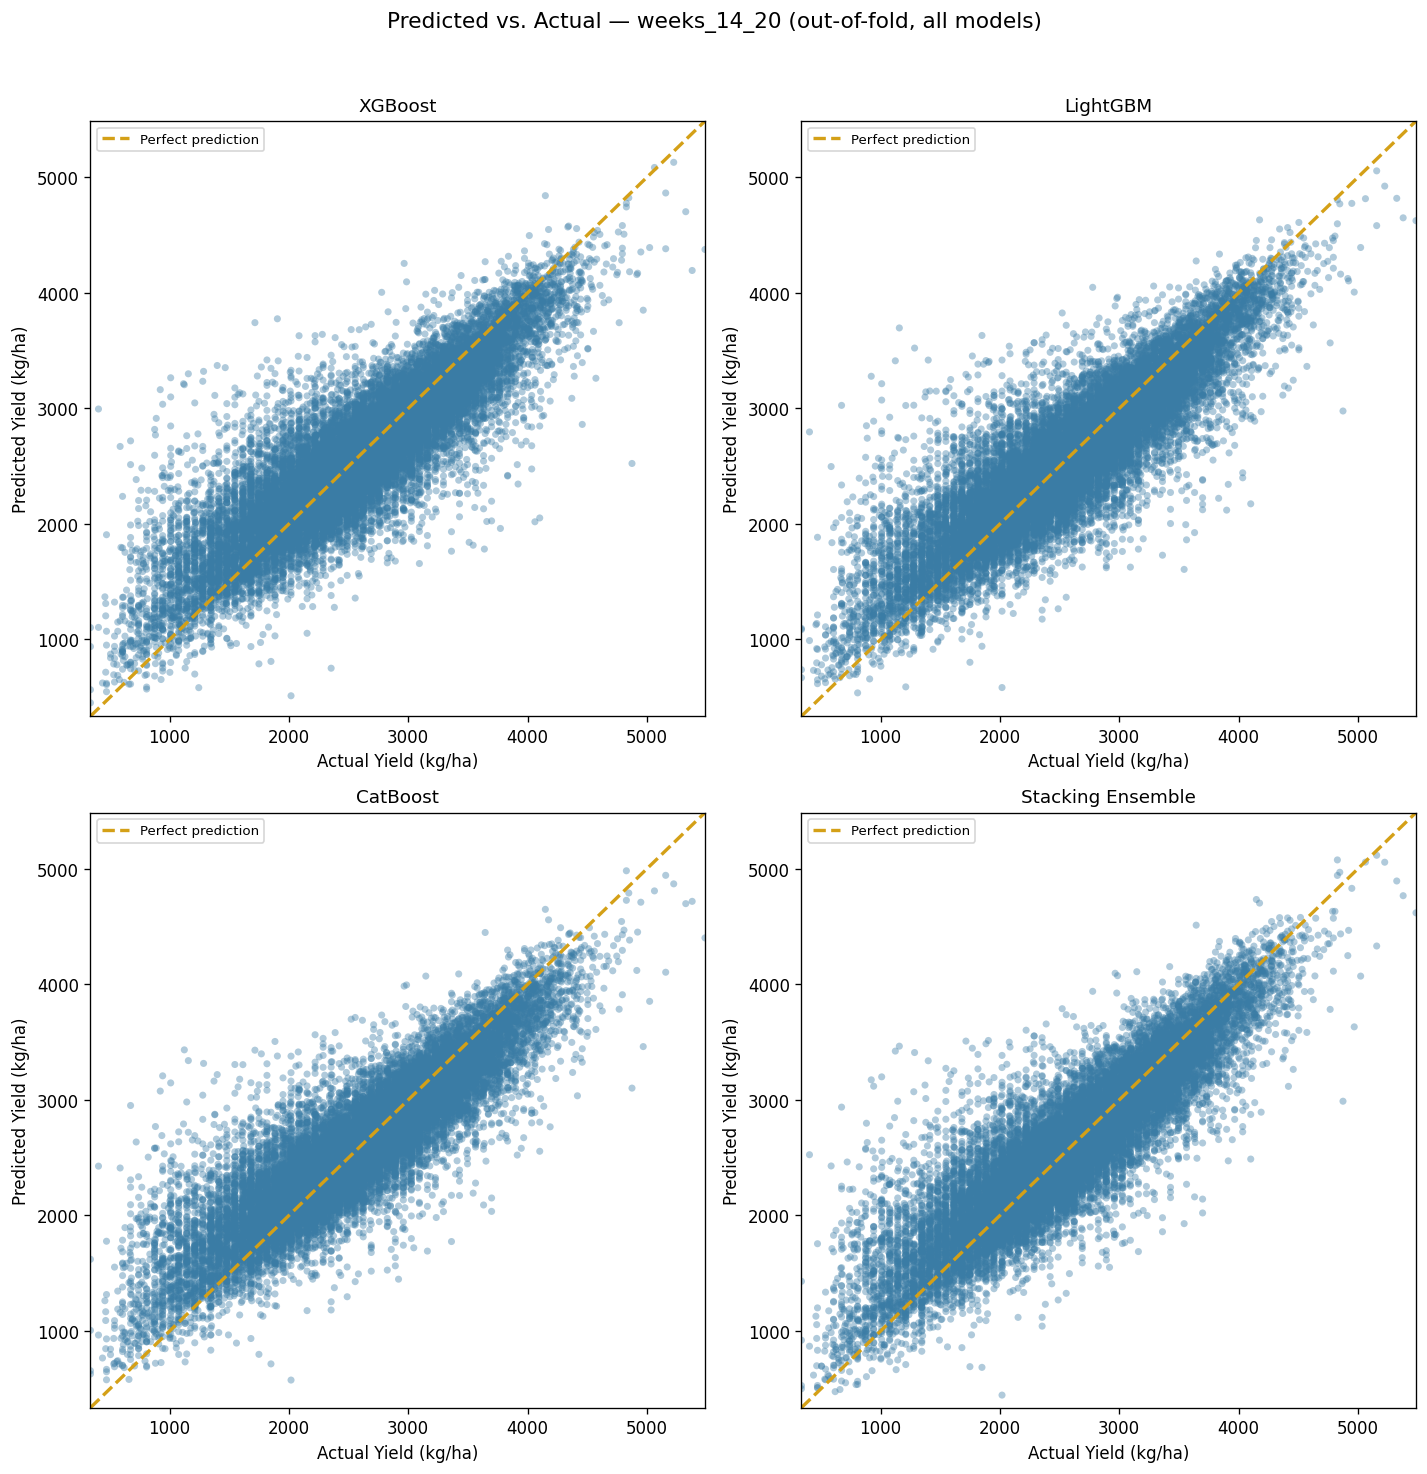

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005345 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12010
[LightGBM] [Info] Number of data points in the train set: 25304, number of used features: 49
[LightGBM] [Info] Start training from score 2589.680456
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005083 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12010
[LightGBM] [Info] Number of data points in the train set: 25304, number of used features: 49
[LightGBM] [Info] Start training from score 2589.680456
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006696 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is n

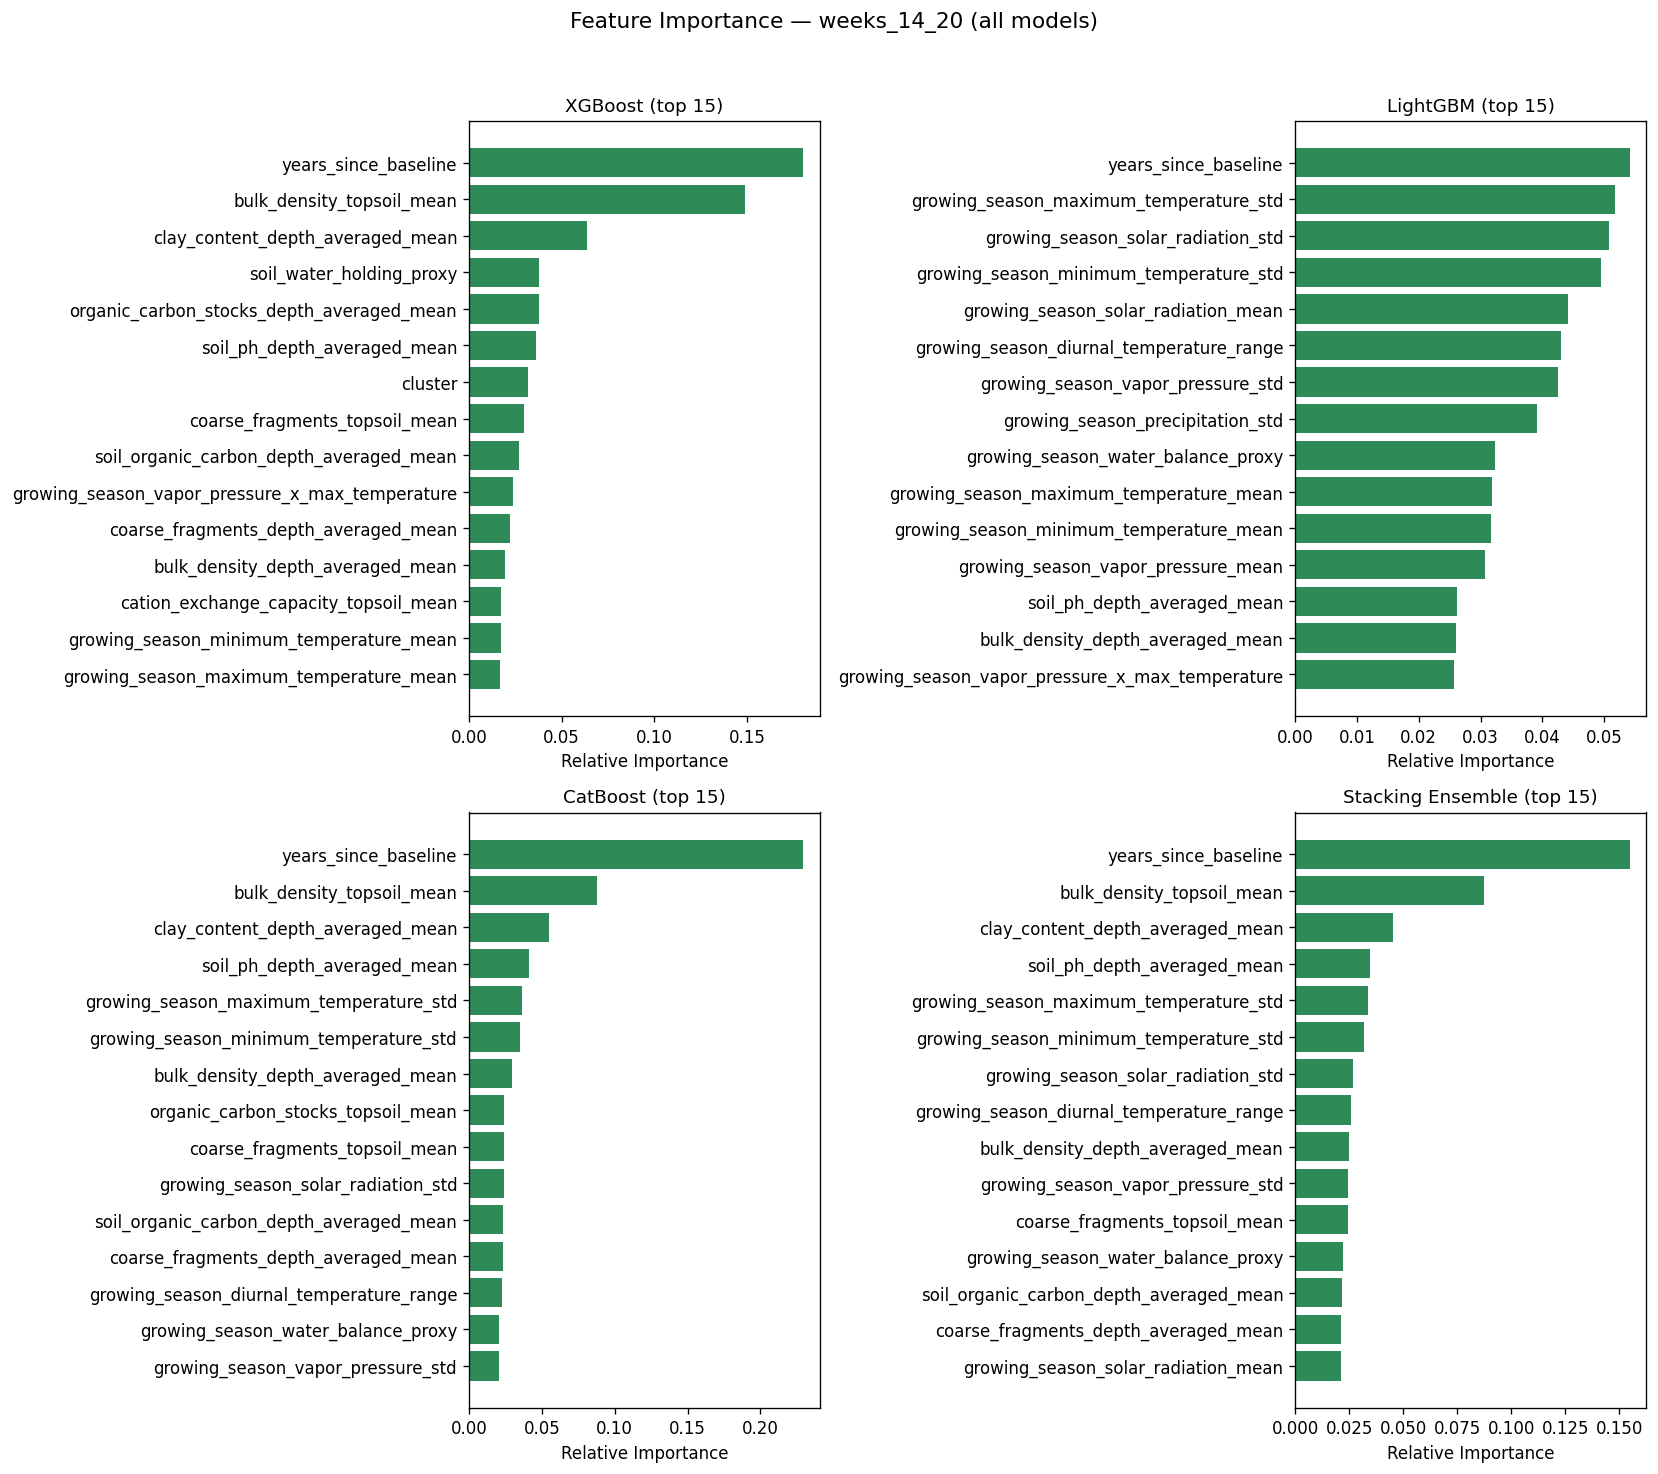

  Top 5 most influential features per model:
   XGBoost:


,feature,importance
0,years_since_baseline,0.180412
1,bulk_density_topsoil_mean,0.148656
2,clay_content_depth_averaged_mean,0.063662
3,soil_water_holding_proxy,0.038063
4,organic_carbon_stocks_depth_averaged_mean,0.037642


   LightGBM:


,feature,importance
0,years_since_baseline,0.054102
1,growing_season_maximum_temperature_std,0.051665
2,growing_season_solar_radiation_std,0.050773
3,growing_season_minimum_temperature_std,0.049544
4,growing_season_solar_radiation_mean,0.044154


   CatBoost:


,feature,importance
0,years_since_baseline,0.229481
1,bulk_density_topsoil_mean,0.087916
2,clay_content_depth_averaged_mean,0.055126
3,soil_ph_depth_averaged_mean,0.041469
4,growing_season_maximum_temperature_std,0.036075


   Stacking Ensemble:


,feature,importance
0,years_since_baseline,0.154665
1,bulk_density_topsoil_mean,0.087128
2,clay_content_depth_averaged_mean,0.045053
3,soil_ph_depth_averaged_mean,0.034630
4,growing_season_maximum_temperature_std,0.033933


RUN: weeks_14_30   weeks 14-30   excluded W_ids=none
STEP 4 — Feature Engineering
  Features used: 49  |  rows: 25,304
  Optuna best for XGBoost: {'n_estimators': 472, 'max_depth': 7, 'learning_rate': 0.10357014098174039}  (CV MSE=123786.6520)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005413 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8923
[LightGBM] [Info] Number of data points in the train set: 4219, number of used features: 49
[LightGBM] [Info] Start training from score 2679.451042
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005499 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11639
[LightGBM] [Info] Number of data points in the train set: 8436, number of used features: 49
[LightGBM] [Info] Start training from score 2672.274730
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overh

,Model,Mean RMSE (kg/ha),Mean R²
0,Stacking Ensemble,325.740803,0.801895
1,CatBoost,332.549427,0.794010
2,LightGBM,343.009523,0.781499
3,XGBoost,347.572120,0.775504


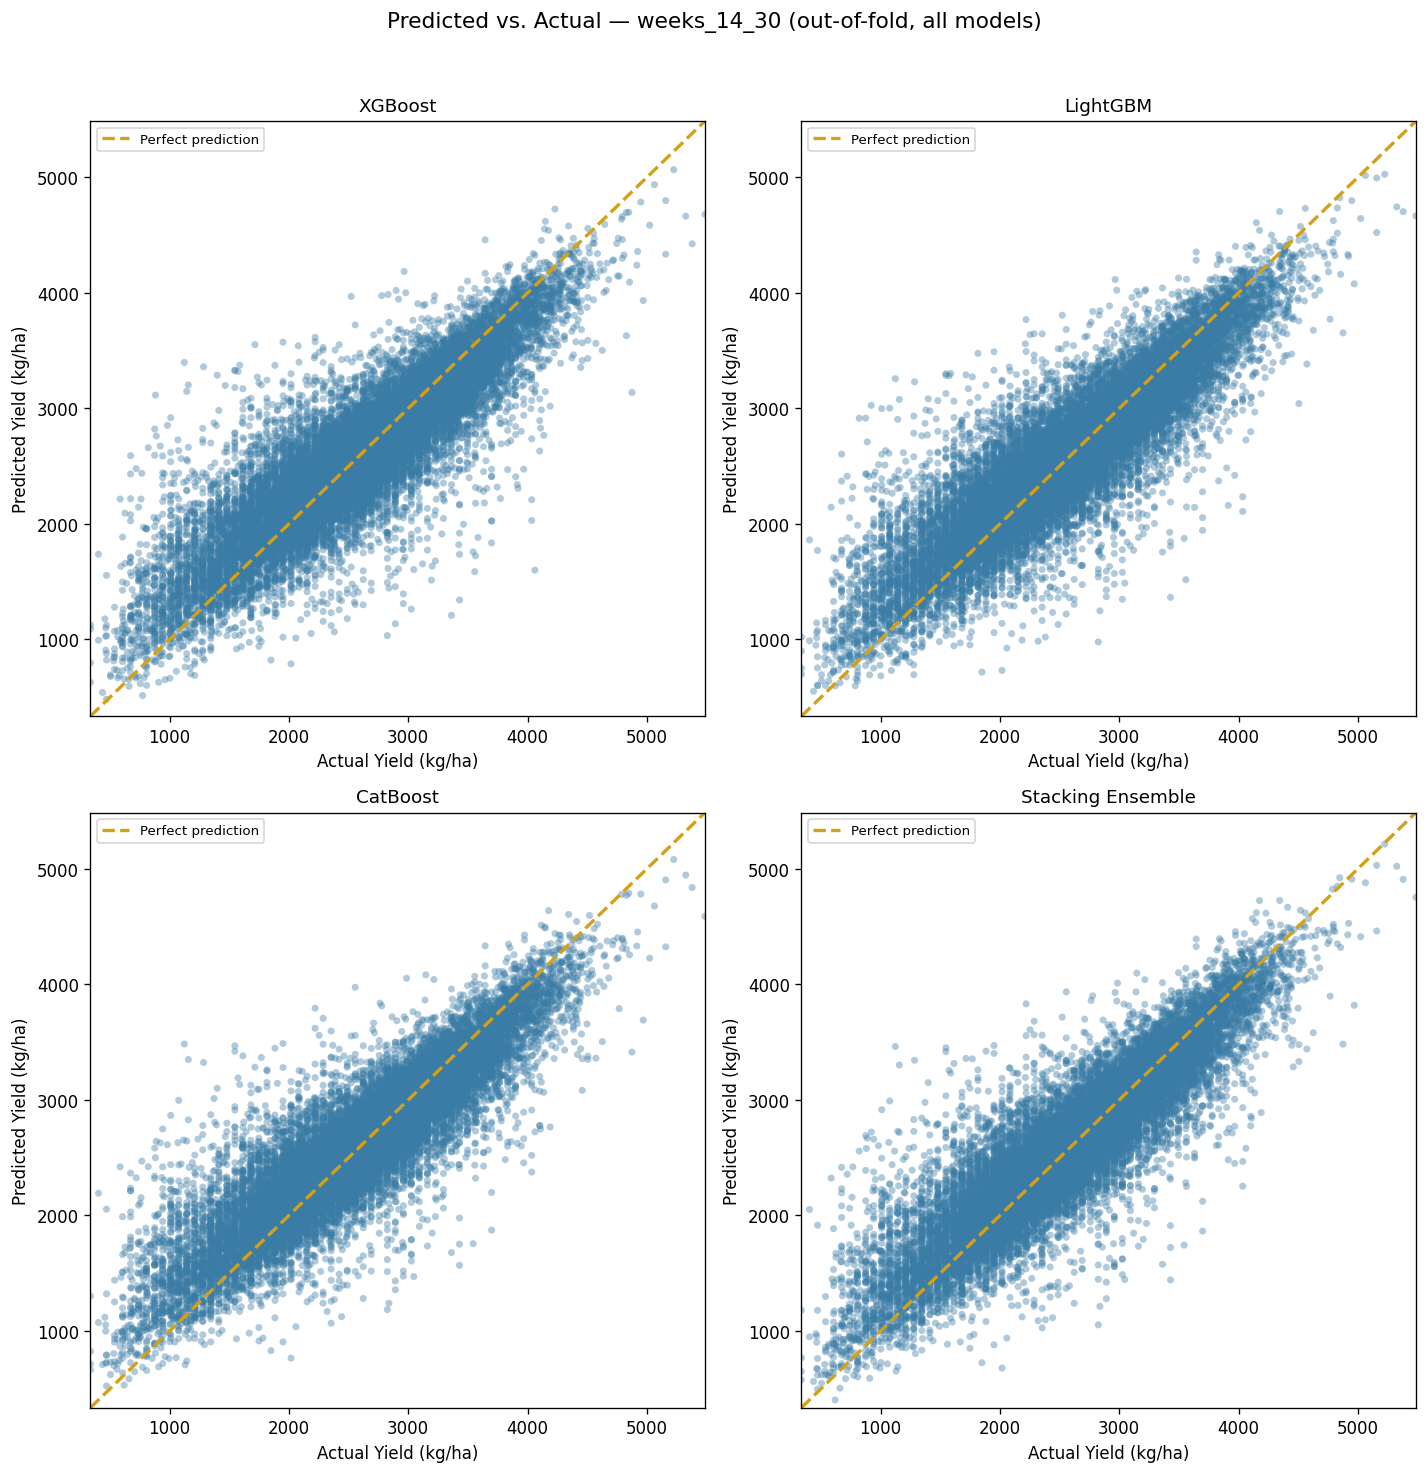

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004882 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12010
[LightGBM] [Info] Number of data points in the train set: 25304, number of used features: 49
[LightGBM] [Info] Start training from score 2589.680456
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005137 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12010
[LightGBM] [Info] Number of data points in the train set: 25304, number of used features: 49
[LightGBM] [Info] Start training from score 2589.680456
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004377 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is n

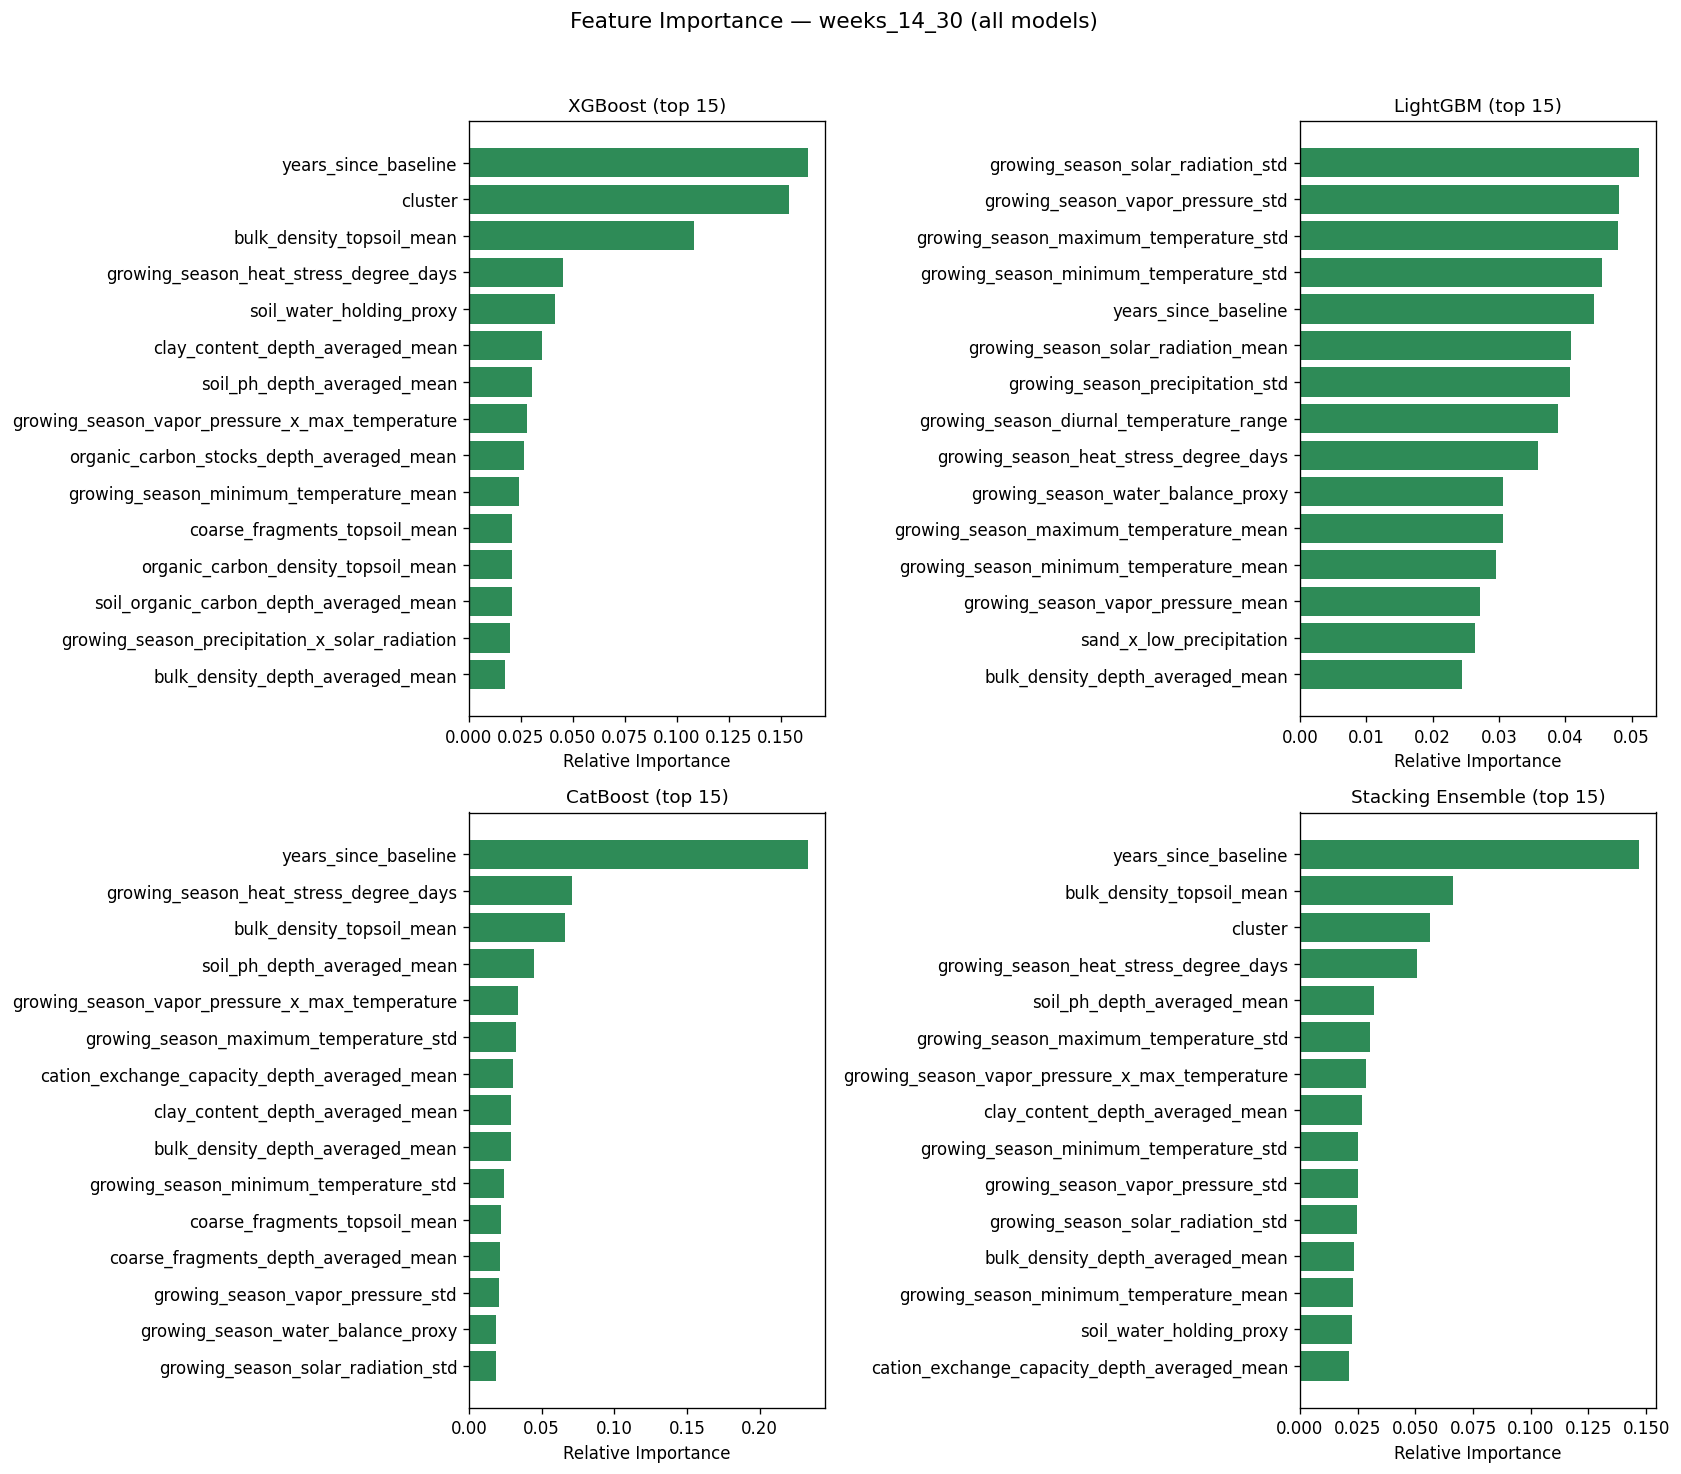

  Top 5 most influential features per model:
   XGBoost:


,feature,importance
0,years_since_baseline,0.163085
1,cluster,0.153968
2,bulk_density_topsoil_mean,0.108388
3,growing_season_heat_stress_degree_days,0.045453
4,soil_water_holding_proxy,0.041227


   LightGBM:


,feature,importance
0,growing_season_solar_radiation_std,0.051125
1,growing_season_vapor_pressure_std,0.048062
2,growing_season_maximum_temperature_std,0.048027
3,growing_season_minimum_temperature_std,0.045494
4,years_since_baseline,0.044382


   CatBoost:


,feature,importance
0,years_since_baseline,0.233343
1,growing_season_heat_stress_degree_days,0.070585
2,bulk_density_topsoil_mean,0.066287
3,soil_ph_depth_averaged_mean,0.044470
4,growing_season_vapor_pressure_x_max_temperature,0.033681


   Stacking Ensemble:


,feature,importance
0,years_since_baseline,0.146937
1,bulk_density_topsoil_mean,0.066144
2,cluster,0.056176
3,growing_season_heat_stress_degree_days,0.050661
4,soil_ph_depth_averaged_mean,0.032284


RUN: weeks_14_40   weeks 14-40   excluded W_ids=none
STEP 4 — Feature Engineering
  Features used: 49  |  rows: 25,304
  Optuna best for XGBoost: {'n_estimators': 672, 'max_depth': 6, 'learning_rate': 0.08375522650699709}  (CV MSE=113030.9744)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004909 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8923
[LightGBM] [Info] Number of data points in the train set: 4219, number of used features: 49
[LightGBM] [Info] Start training from score 2679.451042
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001754 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11639
[LightGBM] [Info] Number of data points in the train set: 8436, number of used features: 49
[LightGBM] [Info] Start training from score 2672.274730
[Li

,Model,Mean RMSE (kg/ha),Mean R²
0,Stacking Ensemble,316.780942,0.812817
1,CatBoost,322.496299,0.806346
2,LightGBM,329.516367,0.797905
3,XGBoost,332.020094,0.795167


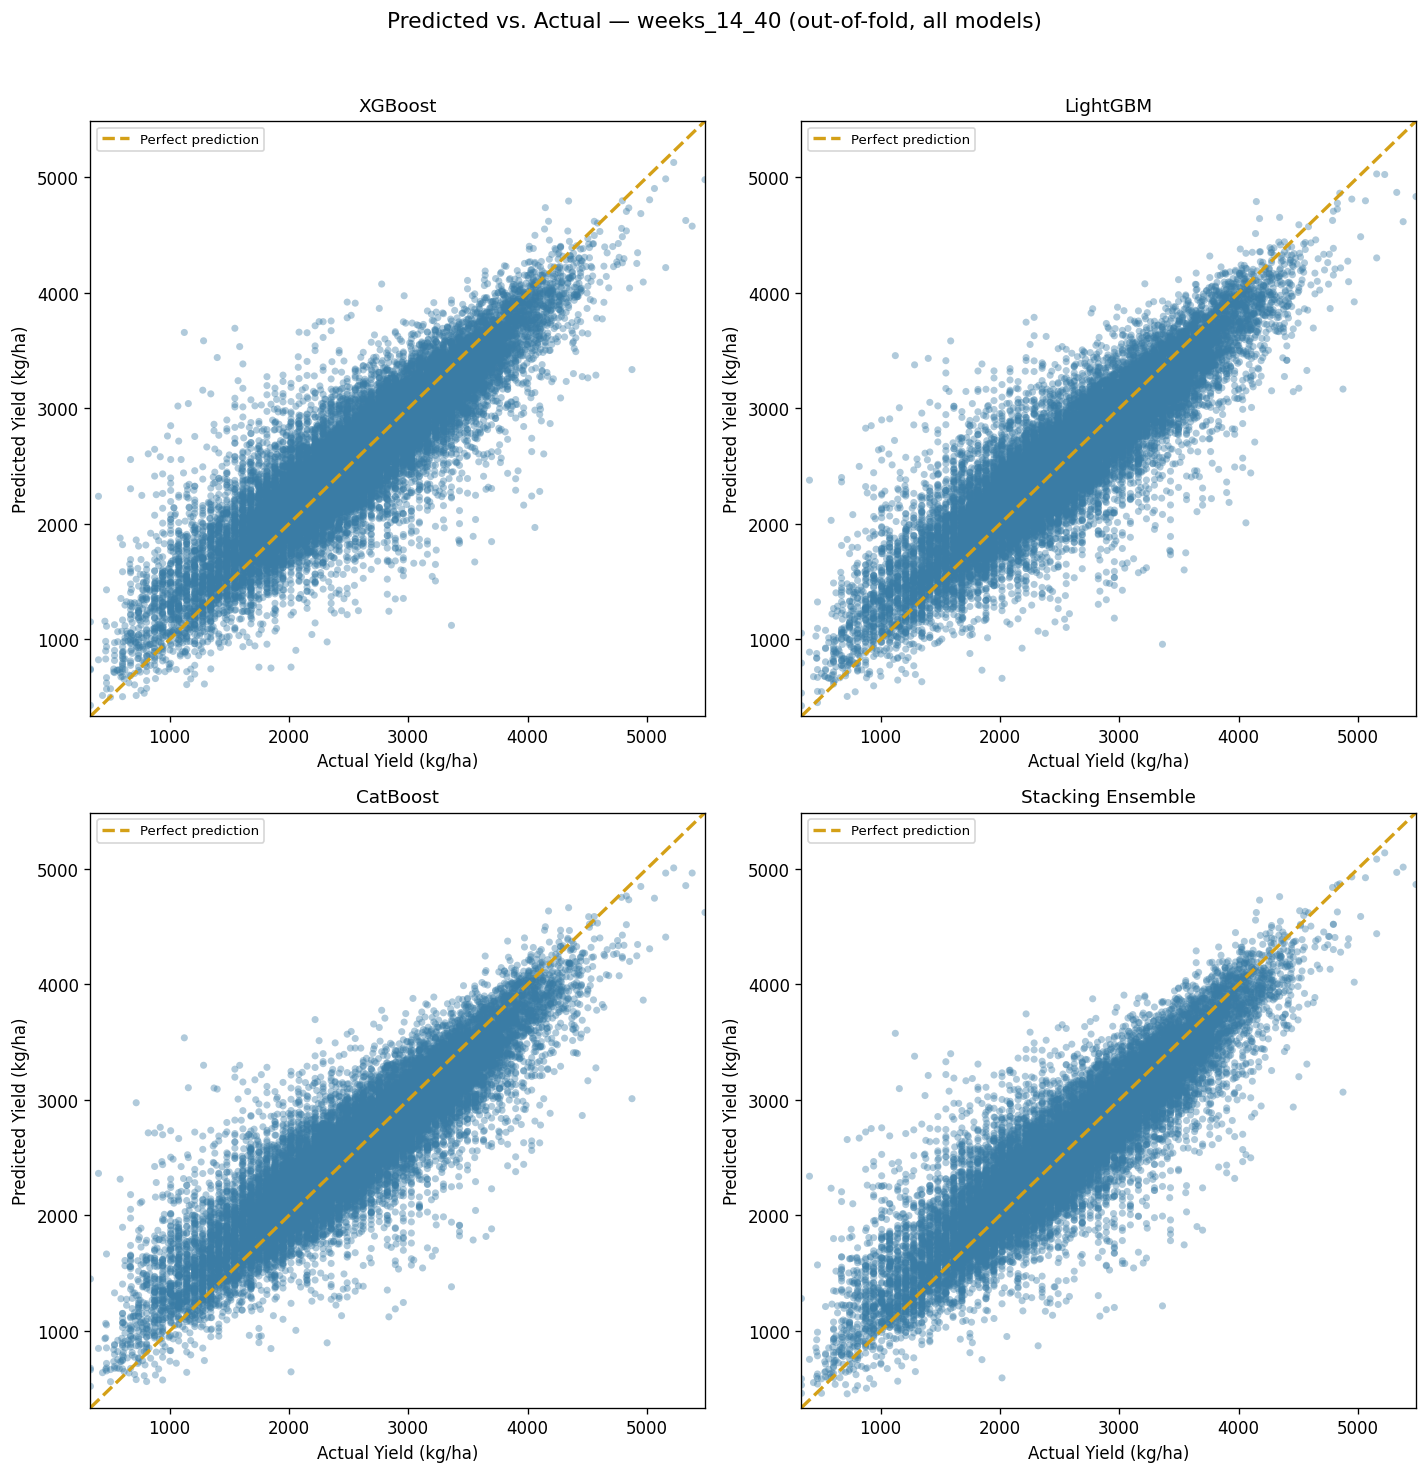

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005051 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12010
[LightGBM] [Info] Number of data points in the train set: 25304, number of used features: 49
[LightGBM] [Info] Start training from score 2589.680456
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005071 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12010
[LightGBM] [Info] Number of data points in the train set: 25304, number of used features: 49
[LightGBM] [Info] Start training from score 2589.680456
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003977 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is n

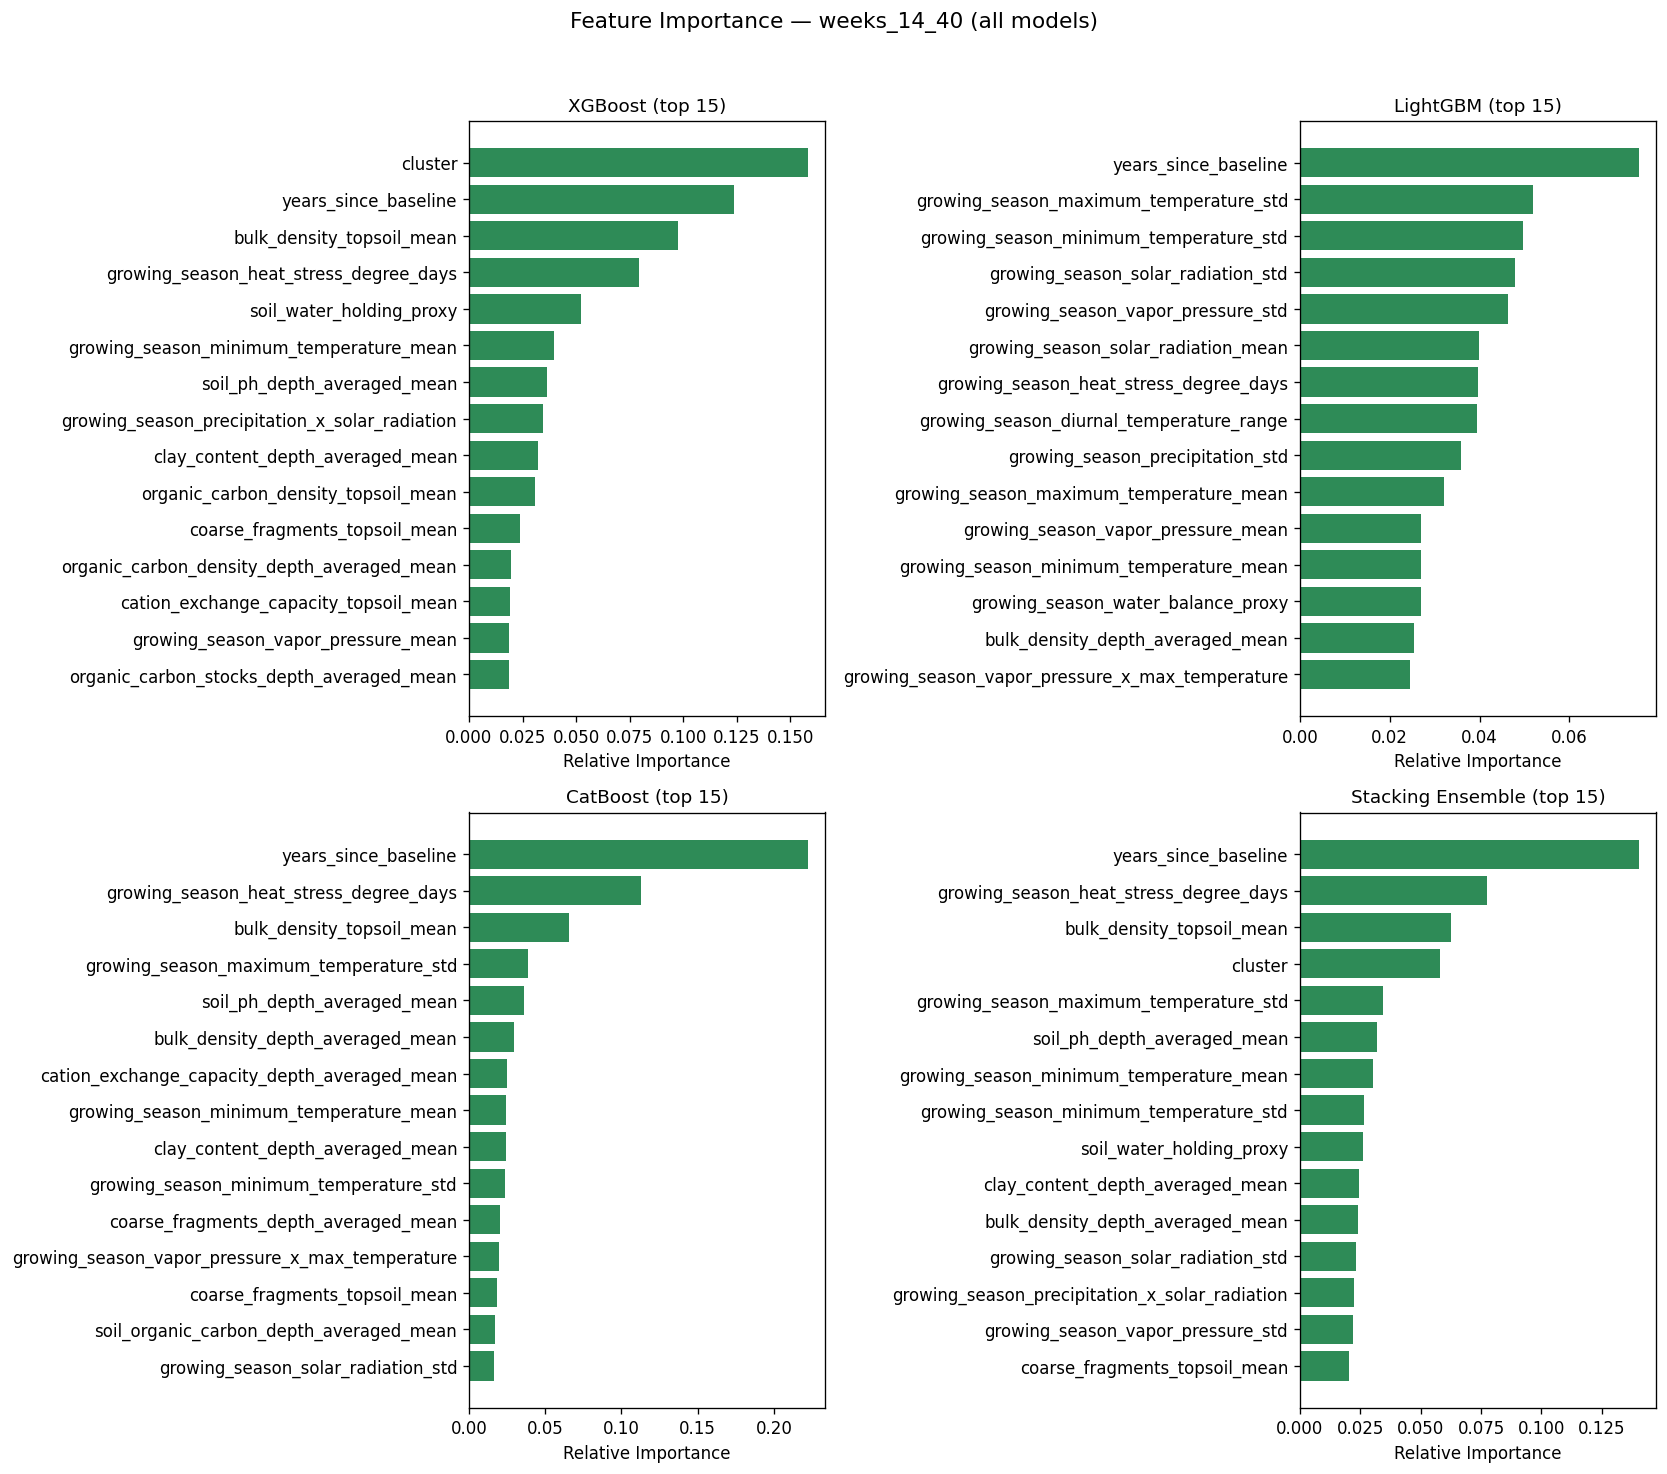

  Top 5 most influential features per model:
   XGBoost:


,feature,importance
0,cluster,0.158188
1,years_since_baseline,0.123538
2,bulk_density_topsoil_mean,0.097557
3,growing_season_heat_stress_degree_days,0.079367
4,soil_water_holding_proxy,0.052231


   LightGBM:


,feature,importance
0,years_since_baseline,0.075490
1,growing_season_maximum_temperature_std,0.051797
2,growing_season_minimum_temperature_std,0.049641
3,growing_season_solar_radiation_std,0.047876
4,growing_season_vapor_pressure_std,0.046373


   CatBoost:


,feature,importance
0,years_since_baseline,0.222277
1,growing_season_heat_stress_degree_days,0.112908
2,bulk_density_topsoil_mean,0.065842
3,growing_season_maximum_temperature_std,0.038609
4,soil_ph_depth_averaged_mean,0.036374


   Stacking Ensemble:


,feature,importance
0,years_since_baseline,0.140435
1,growing_season_heat_stress_degree_days,0.077284
2,bulk_density_topsoil_mean,0.062560
3,cluster,0.057914
4,growing_season_maximum_temperature_std,0.034337



ALL RUNS -- MODEL COMPARISON


,run,Model,Mean RMSE (kg/ha),Mean R²
8,weeks_14_40,Stacking Ensemble,316.780942,0.812817
9,weeks_14_40,CatBoost,322.496299,0.806346
4,weeks_14_30,Stacking Ensemble,325.740803,0.801895
10,weeks_14_40,LightGBM,329.516367,0.797905
11,weeks_14_40,XGBoost,332.020094,0.795167
5,weeks_14_30,CatBoost,332.549427,0.794010
0,weeks_14_20,Stacking Ensemble,339.198583,0.786061
6,weeks_14_30,LightGBM,343.009523,0.781499
7,weeks_14_30,XGBoost,347.572120,0.775504
1,weeks_14_20,CatBoost,349.086409,0.773679


In [15]:
# One tuple per model you want trained: (season_start_week, season_end_week, excluded_weather_ids)
WEEK_RANGE_RUNS = [
    (14, 20, []),   # early season checkpoint
    (14, 30, []),   # mid season checkpoint
    (14, 40, []),   # full season
]

N_TRIALS_MULTI = 30   # lower than the main run's N_TRIALS to keep multi-run experiments fast;
                      # raise once you've picked the ranges you actually want to keep

all_run_results = {}
for (i, j, excl) in WEEK_RANGE_RUNS:
    result = run_full_training(i, j, excluded_weather_ids=excl, n_trials=N_TRIALS_MULTI)
    all_run_results[result['tag']] = result

comparison_across_runs = pd.concat(
    [r['summary'].assign(run=tag) for tag, r in all_run_results.items()],
    ignore_index=True,
)[['run', 'Model', 'Mean RMSE (kg/ha)', 'Mean R²']].sort_values('Mean RMSE (kg/ha)')

print('\n' + '=' * 65)
print('ALL RUNS -- MODEL COMPARISON')
print('=' * 65)
display(comparison_across_runs)


##  STEP 14 - Download All Trained Models (Main Run + Multi-Range Runs)
Zips all saved artifacts (main run + every week-range run) and
downloads them.

In [16]:
import shutil

zip_path = '/content/all_model_artifacts'
shutil.make_archive(zip_path, 'zip', ARTIFACT_DIR)
print(f'  Zipped {ARTIFACT_DIR} -> {zip_path}.zip')

from google.colab import files
files.download(f'{zip_path}.zip')


  Zipped /content/artifacts -> /content/all_model_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>